Analisis Exploratorio de Datos


## Diccionario de datos

El dataset tiene **7,043 clientes** (una fila por cliente) y **21 columnas**.

### Datos del cliente
| Columna | Qué significa | Valores |
|---|---|---|
| customerID | Código que identifica al cliente | Código único |
| gender | Género del cliente | Male / Female |
| SeniorCitizen | Si es adulto mayor | 1 = sí, 0 = no |
| Partner | Si tiene pareja | Yes / No |
| Dependents | Si tiene personas a su cargo | Yes / No |

### Servicios contratados
| Columna | Qué significa | Valores |
|---|---|---|
| PhoneService | Si tiene servicio de teléfono | Yes / No |
| MultipleLines | Si tiene varias líneas telefónicas | Yes / No / No phone service |
| InternetService | Tipo de internet | DSL / Fiber optic / No |
| OnlineSecurity | Servicio de seguridad en línea | Yes / No / No internet service |
| OnlineBackup | Servicio de respaldo en línea | Yes / No / No internet service |
| DeviceProtection | Protección del equipo | Yes / No / No internet service |
| TechSupport | Soporte técnico | Yes / No / No internet service |
| StreamingTV | Televisión por internet | Yes / No / No internet service |
| StreamingMovies | Películas por internet | Yes / No / No internet service |

### Información de la cuenta
| Columna | Qué significa | Valores |
|---|---|---|
| tenure | Meses que lleva el cliente con la empresa | Número (0 a 72) |
| Contract | Tipo de contrato | Month-to-month / One year / Two year |
| PaperlessBilling | Si recibe la factura digital | Yes / No |
| PaymentMethod | Cómo paga | Electronic check / Mailed check / Bank transfer (automatic) / Credit card (automatic) |
| MonthlyCharges | Cuánto paga cada mes | Número |
| TotalCharges | Cuánto ha pagado en total | Número |

### Variable a predecir
| Columna | Qué significa | Valores |
|---|---|---|
| Churn | Si el cliente abandonó la empresa | Yes = se fue, No = sigue |

### Nota sobre "No internet service" y "No phone service"
- Seis columnas de servicios extra (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`,
  `TechSupport`, `StreamingTV`, `StreamingMovies`) tienen el valor **"No internet service"**.
  Significa que el cliente no tiene internet, por eso no puede tener esos servicios.
- `MultipleLines` tiene el valor **"No phone service"**, para los clientes sin teléfono.
- Esa información ya está en `InternetService` y `PhoneService`, así que en el
  preprocesamiento estos valores se reemplazan por **"No"**.


Para empezar cargamos los datos


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Vista general de los datos


In [8]:
df.info()
print("Nulos:", df.isnull().sum().sum())
print("Duplicados:", df.duplicated().sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Aqui vamos a tratar TotalCharges, significa lo que a pagado cada cliente, lo que pasa es que al ejecuatr el codigo anterior se ve que lo interpreta como texto y no como numero, esto pasa porque notamos que unos clientes un espacio en blanco en lugar de un valor, asi que para poder avanzar sin ese problema la convertimos, los espacios vacios fueron rellenados con 0, porque 0? Bueno porque va de la mano con tenure, que como dice la palabra es antiguedad, asi que al poner 0 damos por entendido que esos clientes se acaban de suscribitr o registrar por decirlo asi, no han tenido su primera factura. No se borran ya que solo son 11 filas con ese detalle, asi que es mas facil ponerles 0

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Vacíos:", df["TotalCharges"].isnull().sum())
df[df["TotalCharges"].isnull()][["tenure", "TotalCharges"]]

Vacíos: 11


,tenure,TotalCharges
488,0,NaN
753,0,NaN
936,0,NaN
1082,0,NaN
1340,0,NaN
3331,0,NaN
3826,0,NaN
4380,0,NaN
5218,0,NaN
6670,0,NaN


In [9]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["Churn_num"] = (df["Churn"] == "Yes").astype(int)

Distribucion de Churn=Desercion

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


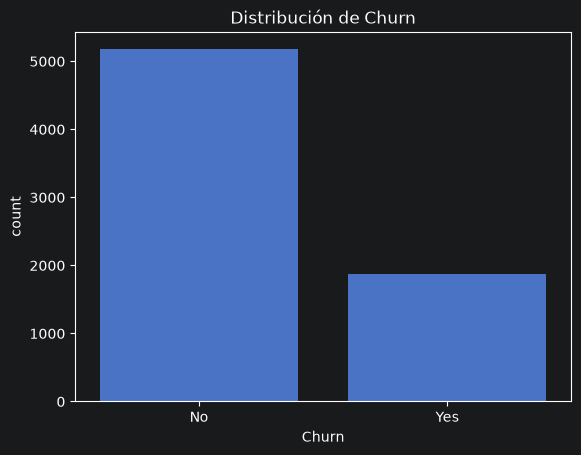

In [10]:
print(df["Churn"].value_counts(normalize=True) * 100)
sns.countplot(x="Churn", data=df)
plt.title("Distribución de Churn")
plt.show()

Aca lo que nos muestra el grafico son los clientes que pertenecen aun, vemos que muy pocos se fueron, puede ser el 26% que desertaron.

Valores de las columnas de texto

In [11]:
for col in ["Contract", "PaymentMethod", "InternetService", "OnlineSecurity"]:
    print(col, df[col].unique())

Contract <ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
PaymentMethod <ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str
InternetService <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


Variables numericas

          tenure  MonthlyCharges  TotalCharges
Churn                                         
No     37.569965       61.265124   2549.911442
Yes    17.979133       74.441332   1531.796094


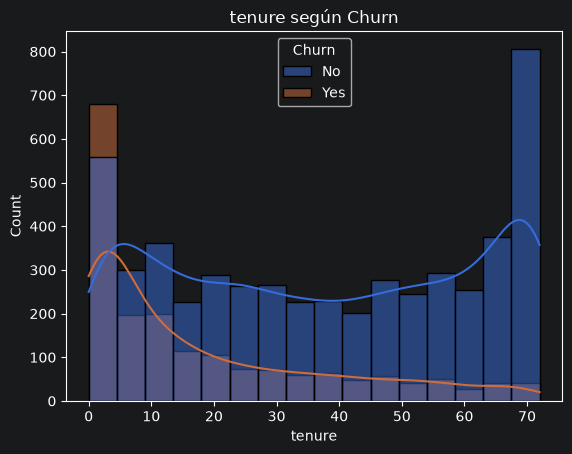

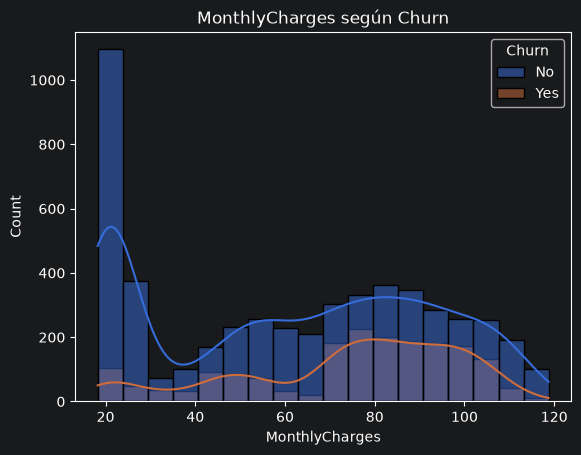

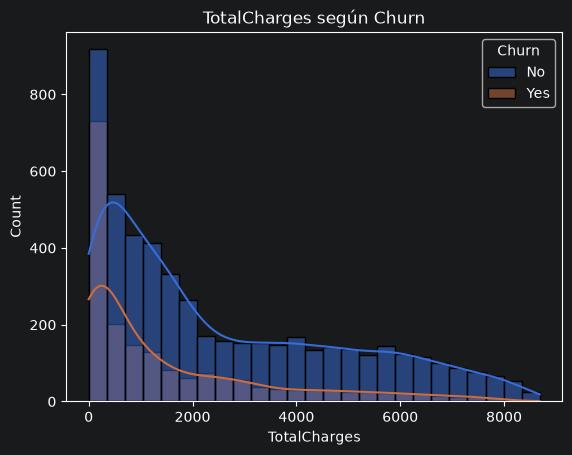

In [13]:
numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
print(df.groupby("Churn")[numericas].mean())

for col in numericas:
    sns.histplot(data=df, x=col, hue="Churn", kde=True)
    plt.title(col + " según Churn")
    plt.show()

Boxplots

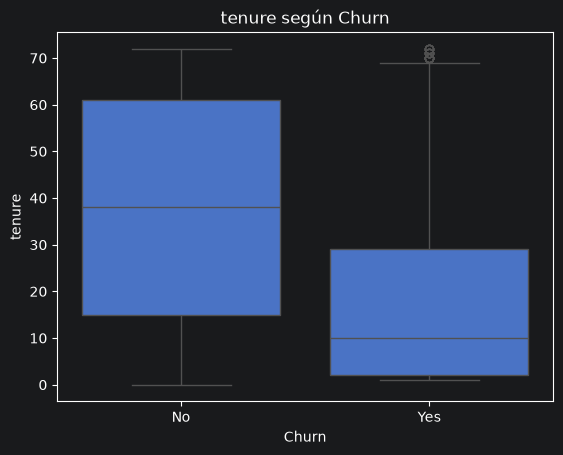

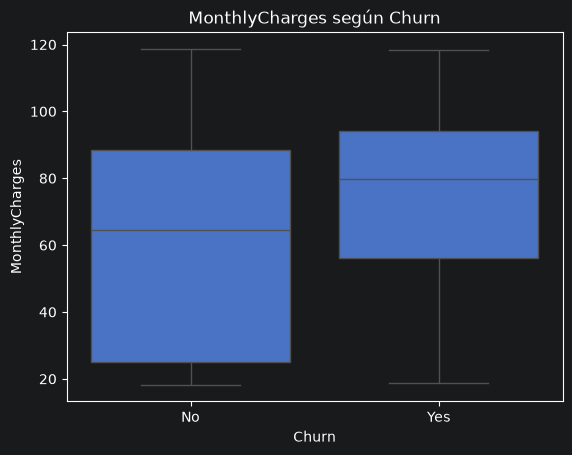

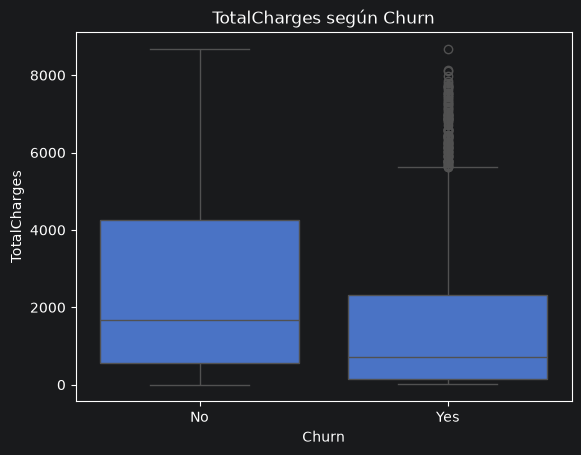

In [14]:
for col in numericas:
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(col + " según Churn")
    plt.show()

Tasa de desercion por segmento

In [19]:
def tasa_churn(col):
    tasa = df.groupby(col, observed=True)["Churn_num"].mean() * 100
    tasa.plot(kind="bar", color="steelblue")
    plt.title("Tasa de churn (%) por " + col)
    plt.ylabel("% churn")
    plt.xticks(rotation=20)
    plt.show()

Datos de cliente y cuenta

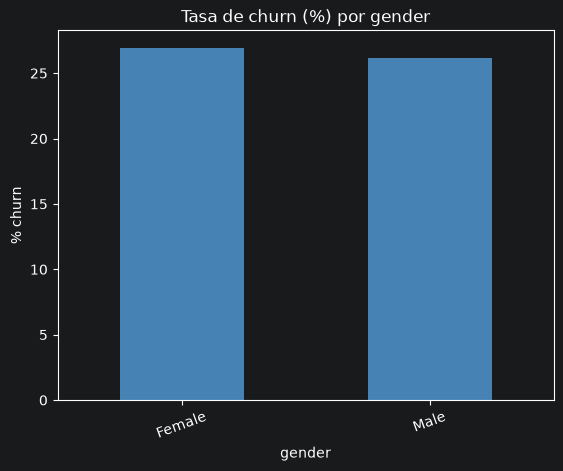

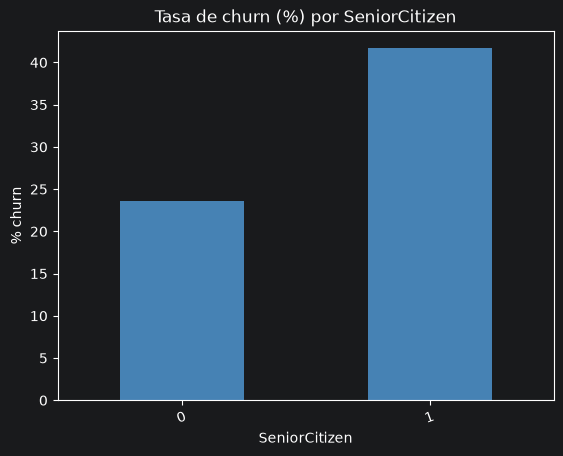

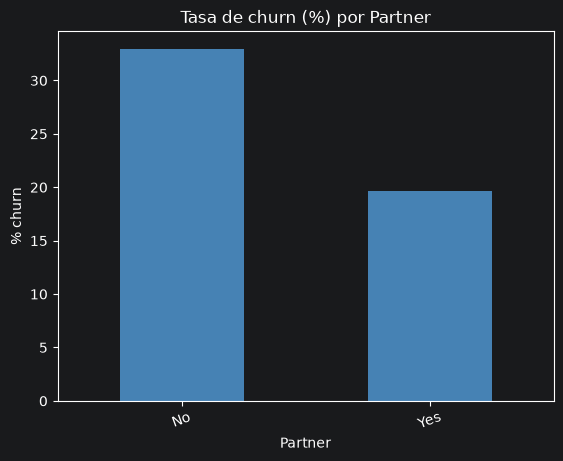

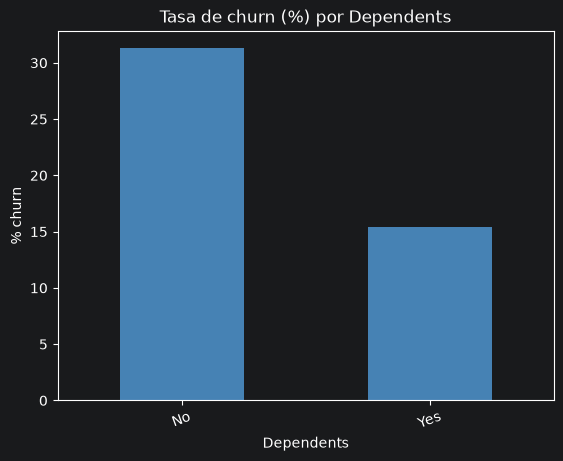

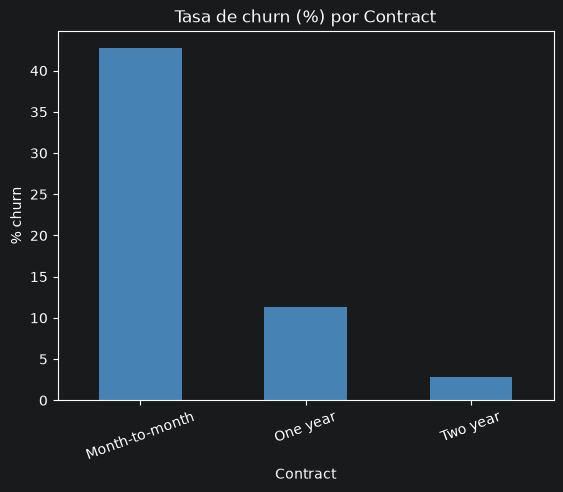

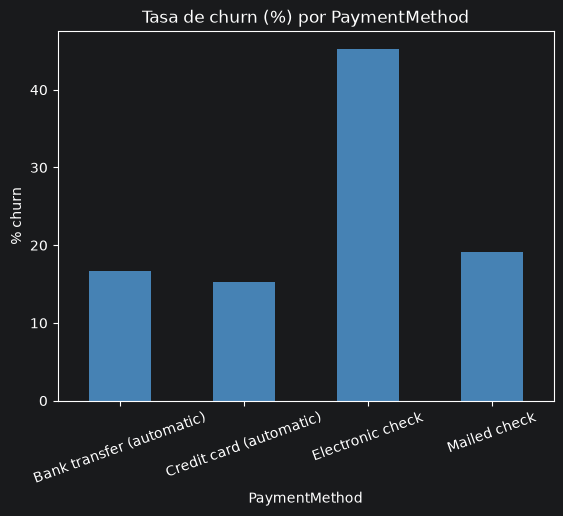

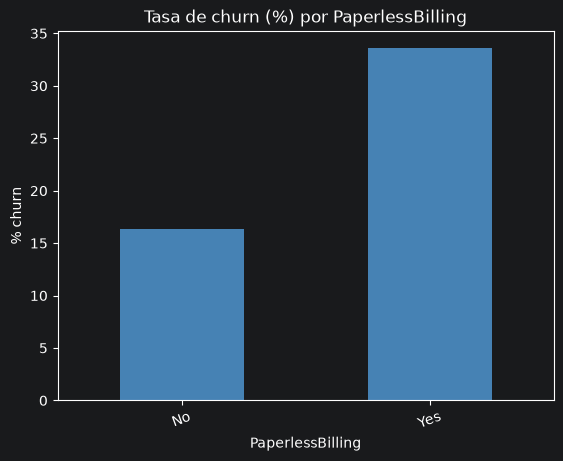

In [18]:
for col in ["gender", "SeniorCitizen", "Partner", "Dependents",
            "Contract", "PaymentMethod", "PaperlessBilling"]:
    tasa_churn(col)

Servicios contratados

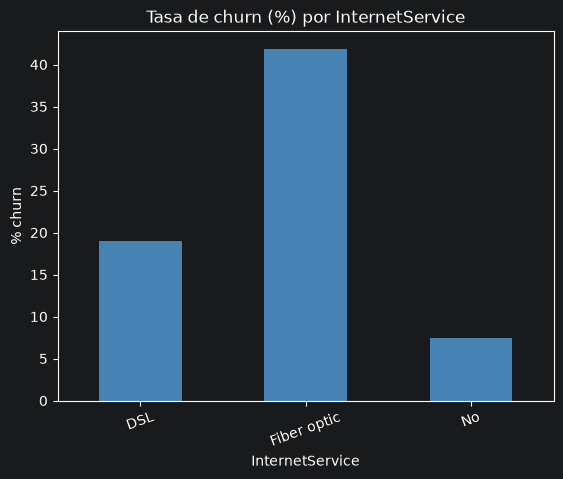

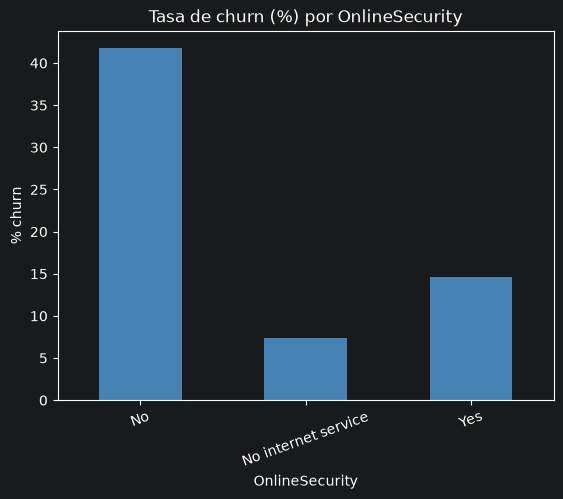

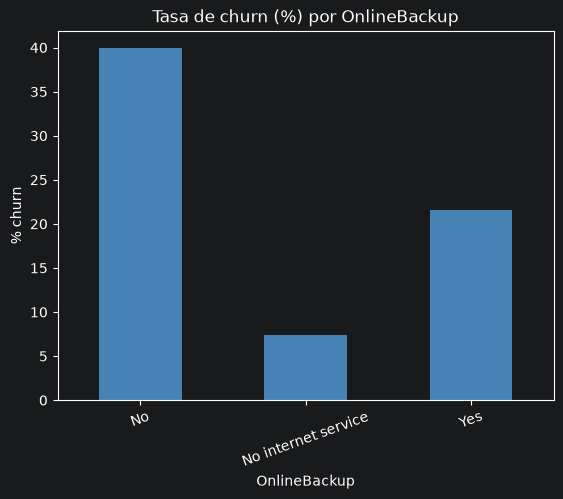

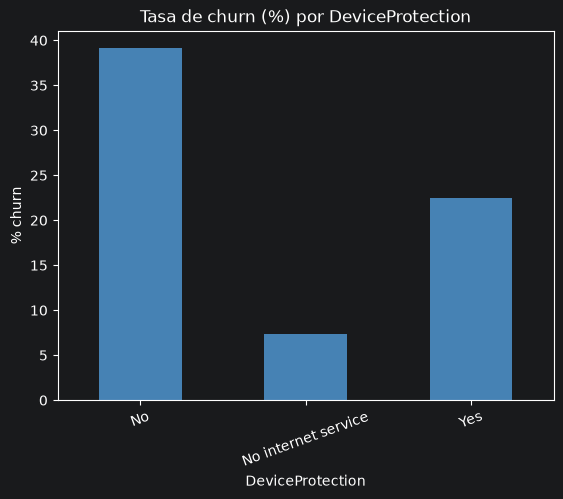

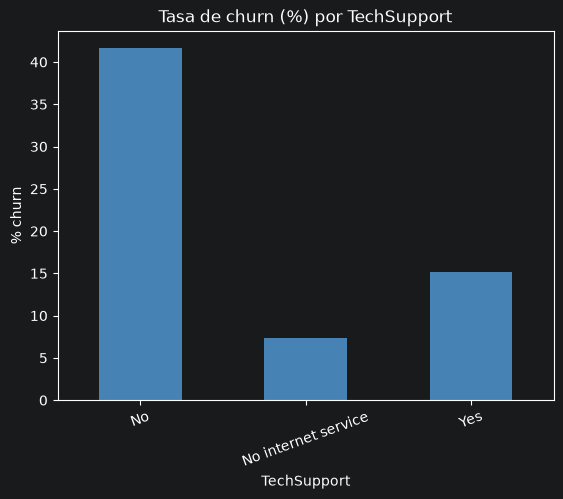

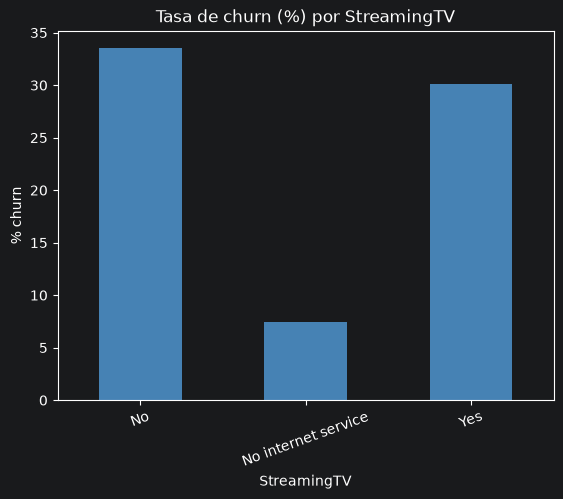

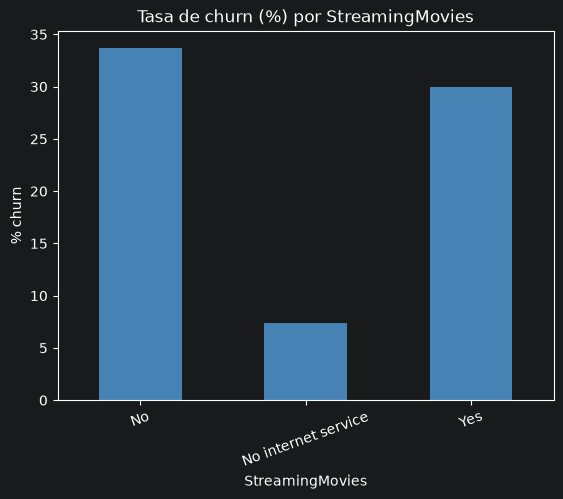

In [20]:
for col in ["InternetService", "OnlineSecurity", "OnlineBackup",
            "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]:
    tasa_churn(col)12

Antiguedad por grupo

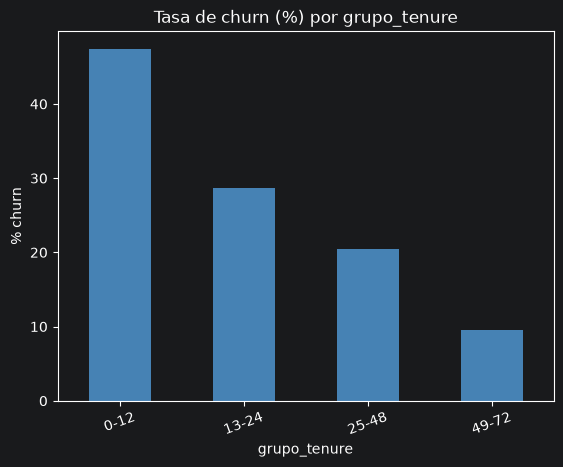

In [21]:
df["grupo_tenure"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                            labels=["0-12", "13-24", "25-48", "49-72"])
tasa_churn("grupo_tenure")

Correlaciones

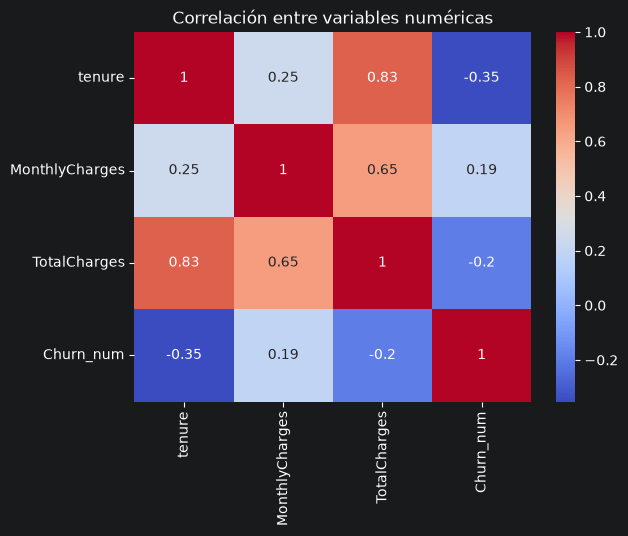

In [22]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn_num"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlación entre variables numéricas")
plt.show()

## Conclusiones del EDA

### Hallazgos principales
- **Desbalance:** cerca del 73% de los clientes se queda y cerca del 27% abandona.
  Al entrenar hay que usar `class_weight`.
- **Variables numéricas:** los clientes que se fueron llevaban en promedio unos 18 meses
  con la empresa, contra unos 38 de los que se quedaron, y pagaban más al mes
  (unos $74 contra unos $61).

### Tasa de churn por segmento (aproximada)
| Variable | Grupo de mayor riesgo | Grupo de menor riesgo |
|---|---|---|
| Contract | Mensual: ≈ 43% | Dos años: ≈ 3% |
| Antigüedad | 0 a 12 meses: ≈ 47% | 49 a 72 meses: ≈ 9% |
| PaymentMethod | Cheque electrónico: ≈ 45% | Tarjeta automática: ≈ 15% |
| InternetService | Fibra óptica: ≈ 42% | Sin internet: ≈ 7% |
| OnlineSecurity | Sin el servicio: ≈ 42% | Con el servicio: ≈ 15% |
| TechSupport | Sin el servicio: ≈ 42% | Con el servicio: ≈ 15% |
| SeniorCitizen | Adulto mayor: ≈ 42% | No adulto mayor: ≈ 24% |
| Partner | Sin pareja: ≈ 33% | Con pareja: ≈ 20% |
| Dependents | Sin dependientes: ≈ 31% | Con dependientes: ≈ 15% |
| PaperlessBilling | Factura digital: ≈ 34% | Factura en papel: ≈ 16% |

### Variables que casi no influyen
- `gender`: las dos barras son casi iguales (≈ 27% contra ≈ 26%).
- `StreamingTV` y `StreamingMovies`: la diferencia entre tenerlos o no es de pocos puntos.

### Conclusión general
El cliente con mayor riesgo de abandonar es **nuevo, con contrato mensual, con fibra
óptica, paga con cheque electrónico y no tiene seguridad en línea ni soporte técnico**.
El cliente con menor riesgo es antiguo, con contrato de uno o dos años y con servicios
de seguridad y soporte.

### Recomendaciones para la empresa
- Ofrecer descuentos o beneficios para pasar a los clientes de contrato mensual a contratos
  de uno o dos años.
- Dar seguimiento especial durante el primer año, que es cuando más clientes se van.
- Promover los servicios de seguridad en línea y soporte técnico, porque los clientes que
  los tienen se quedan más.
- Revisar la calidad del servicio de fibra óptica y el proceso de pago con cheque electrónico.